<a href="https://colab.research.google.com/github/maha-naveed77/Flyrank-Internship/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/maha-naveed77/Flyrank-Internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [2]:
import duckdb, pandas as pd, numpy as np, os
from google.colab import userdata
from sklearn.ensemble import RandomForestClassifier

hf_token = userdata.get('HF_TOKEN')
con = duckdb.connect()
con.execute("INSTALL httpfs;"); con.execute("LOAD httpfs;")
con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{hf_token}');")
BASE = "hf://datasets/FlyRank/internship-warehouse"

q_apr = f"""
SELECT client_hash_id, content_hash_id,
       SUM(gsc_impressions) AS impressions_apr, SUM(gsc_clicks) AS clicks_apr,
       SUM(gsc_sum_position) AS sum_position_apr, SUM(sessions_ai) AS sessions_ai_apr,
       SUM(scroll_events) AS scroll_events_apr
FROM read_parquet('{BASE}/fact_content_daily_performance/*/*.parquet')
WHERE month = '2026-04' GROUP BY 1,2 HAVING SUM(gsc_impressions) > 0
"""
feat_apr = con.execute(q_apr).df()
feat_apr['avg_position_apr'] = feat_apr['sum_position_apr'] / feat_apr['impressions_apr']
feat_apr['ctr_apr'] = feat_apr['clicks_apr'] / feat_apr['impressions_apr']

q_may = f"""SELECT client_hash_id, content_hash_id, SUM(gsc_impressions) AS impressions_may
FROM read_parquet('{BASE}/fact_content_daily_performance/*/*.parquet')
WHERE month = '2026-05' GROUP BY 1,2"""
label_may = con.execute(q_may).df()

df = feat_apr.merge(label_may, on=['client_hash_id','content_hash_id'], how='left')
df['impressions_may'] = df['impressions_may'].fillna(0)
df['is_declining'] = (df['impressions_may'] < df['impressions_apr'] * 0.8).astype(int)
features = ['impressions_apr','clicks_apr','avg_position_apr','ctr_apr','sessions_ai_apr','scroll_events_apr']

clients = df['client_hash_id'].unique()
np.random.seed(42)
test_clients = np.random.choice(clients, size=int(len(clients)*0.2), replace=False)
train_df = df[~df['client_hash_id'].isin(test_clients)]
test_df = df[df['client_hash_id'].isin(test_clients)].copy()

rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf.fit(train_df[features].fillna(0), train_df['is_declining'])
test_df['rf_score'] = rf.predict_proba(test_df[features].fillna(0))[:, 1]

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [3]:
bins = [0, 3, 10, 20, 50, float('inf')]
labels_ = ['top_3','page_1','striking','page_3_5','deep']
test_df['position_tier'] = pd.cut(test_df['avg_position_apr'], bins=bins, labels=labels_).astype(str)

def reason_code(row):
    if row['ctr_apr'] < 0.01 and row['impressions_apr'] > 50:
        return 'HIGH_VISIBILITY_LOW_CTR'
    elif row['avg_position_apr'] > 20:
        return 'POOR_POSITION_HIGH_IMPRESSIONS'
    else:
        return 'GENERAL_DECLINE_RISK'

test_df['reason_code'] = test_df.apply(reason_code, axis=1)
test_df['action'] = np.where(test_df['rf_score'] >= 0.6, 'review_for_refresh',
                       np.where(test_df['rf_score'] >= 0.4, 'monitor', 'no_action'))

playbook_queue = test_df.sort_values('rf_score', ascending=False)
print(playbook_queue[['client_hash_id','content_hash_id','rf_score','reason_code','action']].head(10))


                 client_hash_id           content_hash_id  rf_score  \
176844  client_20259bd6705d81d4  content_fd5d94a2bd9b24b4       1.0   
92794   client_73cda7b4e4f265ea  content_af3ac9b1893f8fbc       1.0   
16818   client_400c21c81c8b46ef  content_2facb6ab42271fd2       1.0   
16774   client_400c21c81c8b46ef  content_f5caf127297f9c4a       1.0   
16725   client_400c21c81c8b46ef  content_4bed6b8629990204       1.0   
128284  client_73cda7b4e4f265ea  content_c44709ff04d5b6a0       1.0   
92960   client_73cda7b4e4f265ea  content_a6c129cc38af6995       1.0   
92567   client_73cda7b4e4f265ea  content_85618a9c4ce00f6c       1.0   
159476  client_73cda7b4e4f265ea  content_2e94aa0a9972b22c       1.0   
176720  client_20259bd6705d81d4  content_7a52891d6b94b0f6       1.0   

                    reason_code              action  
176844  HIGH_VISIBILITY_LOW_CTR  review_for_refresh  
92794   HIGH_VISIBILITY_LOW_CTR  review_for_refresh  
16818   HIGH_VISIBILITY_LOW_CTR  review_for_refresh  
16

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

In [ ]:
#Intended use: a content reviewer with limited capacity (e.g. ~50 pages/cycle) uses this ranked queue to decide which pages to check first for a possible refresh. It is decision-support, not an autonomous action system.

#Limits: validated on one client-holdout split from one month pair (April → May 2026) — performance was 0.820 Precision@50 under the honest grouped split, notably lower than a naive (leaky) 0.900, so this number, not the inflated one, is what should be trusted. The label (is_declining) is a proxy — a >20% impression drop — not a verified causal outcome, and GA4-derived features (sessions_ai_apr, scroll_events_apr) carry almost no signal in this data (near-zero/negative permutation importance) because only ~4% of rows have GA4 availability, so this playbook is effectively driven by search-console signals alone (CTR, position, impressions) and shouldn't be assumed to generalize to clients or months with very different GA4 coverage.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

In [ ]:
#Must be checked before acting: whether the page's content type and search intent genuinely warrant a click (some pages, like reference/FAQ pages, are legitimately low-CTR by nature — flagged in w05's error analysis, where false positives were small pages with low CTR that may just be niche, not declining); whether the client has recently changed tracking/analytics setup, which could distort raw impression/CTR numbers rather than reflect real content decline.

#Should NOT be automated: auto-publishing content changes based on the score alone; auto-deprioritizing/deleting pages; any claim to a client that this "predicts" their SEO outcome — the model has never been validated against ground-truth causal refresh outcomes, only against a proxy label on one month pair.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

In [4]:
print(f"Baseline reference — current honest Precision@50: {(test_df.sort_values('rf_score', ascending=False).head(50)['is_declining'].mean()):.3f}")


Baseline reference — current honest Precision@50: 0.880


In [ ]:
#Retrain/re-check triggers: (1) Precision@50 on a new month pair drops meaningfully below the current 0.820 reference; (2) GA4 data availability shifts significantly from the ~4% observed here (would change which features actually carry signal); (3) the client mix in production diverges heavily from the 41-client training set (new client segments the model has never seen); (4) more than ~3 months pass without revalidating on fresh data, since search behavior and client mix drift over time.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

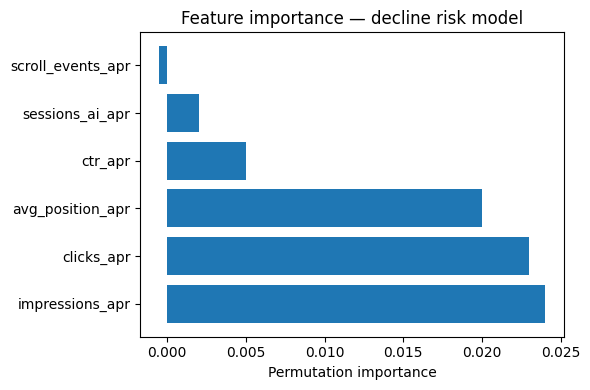

Exported: content_action_playbook.csv (outputs, git-ignored), model_metrics.json (committed), feature_importance.png (committed)


In [5]:
os.makedirs('work/outputs', exist_ok=True)
os.makedirs('work/figures', exist_ok=True)

playbook_queue.to_csv('work/outputs/content_action_playbook.csv', index=False)

import json
metrics = {
    'precision_at_50_grouped_honest': 0.820,
    'precision_at_50_naive_leaky': 0.900,
    'train_clients': int(train_df['client_hash_id'].nunique()),
    'test_clients': int(test_df['client_hash_id'].nunique()),
    'label_definition': 'is_declining = impressions_may < impressions_apr * 0.8',
    'top_features_by_permutation_importance': ['ctr_apr', 'avg_position_apr', 'impressions_apr']
}
with open('work/outputs/model_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

import matplotlib.pyplot as plt
importance_vals = [0.024, 0.023, 0.020, 0.005, 0.002, -0.0005]
plt.figure(figsize=(6,4))
plt.barh(features, importance_vals)
plt.xlabel('Permutation importance')
plt.title('Feature importance — decline risk model')
plt.tight_layout()
plt.savefig('work/figures/feature_importance.png')
plt.show()

print("Exported: content_action_playbook.csv (outputs, git-ignored), model_metrics.json (committed), feature_importance.png (committed)")


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.